# blazarkit — Demo Notebook

This notebook walks you through using **blazarkit** to load pre-computed
spectral fitting results and reproduce all diagnostic plots for Fermi-detected
blazars from the SDSS-V DR20 survey.

---

### What are blazars?
Blazars are a subclass of radio loud AGNs  with
relativistic plasma jets pointed directly toward Earth. This pipeline fits
their optical spectra by decomposing the light into jet, host galaxy, and
accretion disc contributions.

---

### Before you start
1. Install blazarkit:
   `pip install git+https://github.com/minlowie/Blazar-Analysis-Pipeline.git`
2. Download the cache from Zenodo: **DOI: to be added upon publication**
3. Place the cache folder in a location of your choice and update CACHE_DIR below

---

### Reference
Nlowie et al. (in prep.) — *Optical Spectroscopic Analysis of Fermi Detected Blazars using SDSS-V*

## 0. Imports

In [24]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#Making sure blazarkit is reloaded to reflect recent changes
import importlib
import blazarkit
importlib.reload(blazarkit)

from blazarkit import (
    RedshiftResultsCache,
    plot_from_cache,
    plot_multi_object_comparison_single,
    compute_EW_for_all_lines,
    normalize_shape,
    get_redshift_peaks,
    classification_summary,
    compare_epochs,
    plot_population,
    plot_ew_summary,
)

print('blazarkit imported successfully.')

blazarkit imported successfully.


## 1. Initialise the cache

Point `CACHE_DIR` to wherever you downloaded the cache folder.
Each file in the cache is named `obj_{SDSS_ID}_{MJD}.pkl.gz`.
The SDSS_ID and MJD can also be found in the VAC table on the SDSS SAS.

In [4]:
CACHE_DIR = '/Users/NAK/Desktop/test_cache'  # ← update this path to your cache directory

cache = RedshiftResultsCache(cache_dir=CACHE_DIR)
cached_files = cache.list_cached_objects()

# Show the first 2 cached sources 
print('\nFirst 2 cached sources:')
for f in sorted(cached_files)[:2]:
    print(f'  {f}')

Found 3 cached objects in /Users/s2822744/Desktop/test_cache/

First 2 cached sources:
  obj_13362106_59199.pkl.gz
  obj_15606475_60162.pkl.gz


## 2. Load a single source

We will use SDSS_ID = 20570296 (MJD = 60027) as our main example throughout
this notebook. This is a BL Lac candidate from the sample.

To use a different source, replace SDSS_ID and MJD with values from your
cache directory or from the VAC table.

In [25]:
SDSS_ID = '20570296'   # ← replace with any SDSS_ID from your cache
MJD     = 60027        # ← replace with the corresponding MJD

results = cache.load_object_results(SDSS_ID, mjd=MJD)

# Print a full summary
meta  = results['metadata']
lmfit = results['lmfit_results']
comp  = results['components']

print(f"\n{'='*55}")
print(f"SDSS_ID:       {meta['SDSS_ID']}")
print(f"Fermi class:   {meta['fermi_class']}")
print(f"SDSS class:    {meta['obj_class']}")
print(f"S/N:           {meta['sn_median']:.1f}")
print(f"{'─'*55}")
print(f"Best model:    {lmfit['best_label']}")
print(f"z_fit:         {lmfit['z_best']:.4f}")
print(f"z_SDSS:        {meta['z_sdss']}")
print(f"AICc margin:   {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:      {lmfit['pl_alpha']:.4f}")
print(f"PL delta:      {lmfit['pl_delta']:.4f}")

# Jet fraction
best = lmfit['best_label']
if best == 'Powerlaw+Galaxy' and comp['galpl_contrib'] is not None:
    print(f"Jet fraction:  {comp['galpl_contrib']['frac_pl']*100:.1f}%")
    print(f"Host fraction: {comp['galpl_contrib']['frac_tpl']*100:.1f}%")
elif best.startswith('Powerlaw+QSO') and comp['qsopl_contrib'] is not None:
    print(f"Jet fraction:  {comp['qsopl_contrib']['frac_pl']*100:.1f}%")
    print(f"Disc/BLR:      {comp['qsopl_contrib']['frac_tpl']*100:.1f}%")
elif best.startswith('Powerlaw+Lines') and comp['linepl_contrib'] is not None:
    print(f"Jet fraction:  {comp['linepl_contrib']['frac_pl']*100:.1f}%")
print(f"{'='*55}")

Loaded: obj_20570296_60027.pkl.gz

SDSS_ID:       20570296
Fermi class:   fsrq
SDSS class:    QSO
S/N:           10.5
───────────────────────────────────────────────────────
Best model:    Powerlaw+Lines (High Blueshift Line)
z_fit:         0.9961
z_SDSS:        0.9996569156646729
AICc margin:   49.0
PL alpha:      -1.2969
PL delta:      -1.2000
Jet fraction:  90.7%


## 3. Default plot

`plot_from_cache` produces two figures:

- **Figure 1** — χ²(z) curves and redshift posterior p(z) for all six model
  families, showing how the pipeline selected the best redshift
- **Figure 2** — Best-fit spectrum with component decomposition, spectral
  line markers, zoom insets on detected features, and normalised residuals

/Users/s2822744/Desktop/Blazar-Analysis-Pipeline/blazarkit.py:573: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


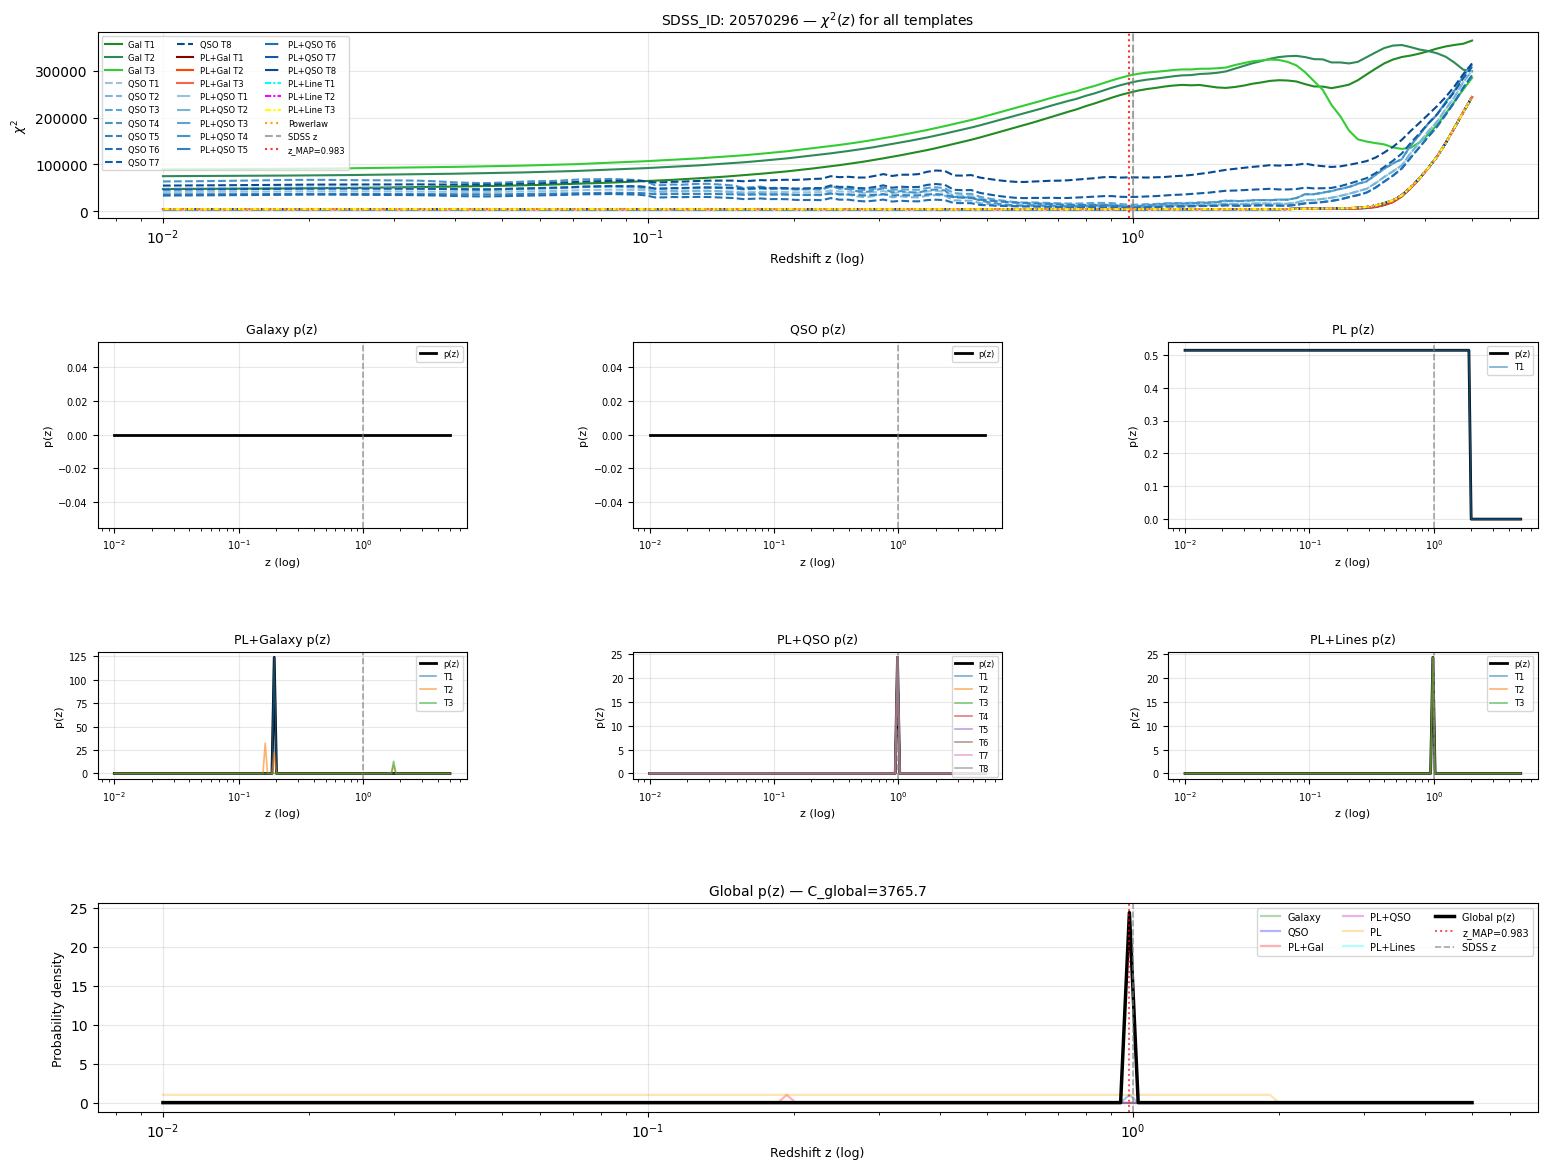

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


/Users/s2822744/Desktop/Blazar-Analysis-Pipeline/blazarkit.py:773: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


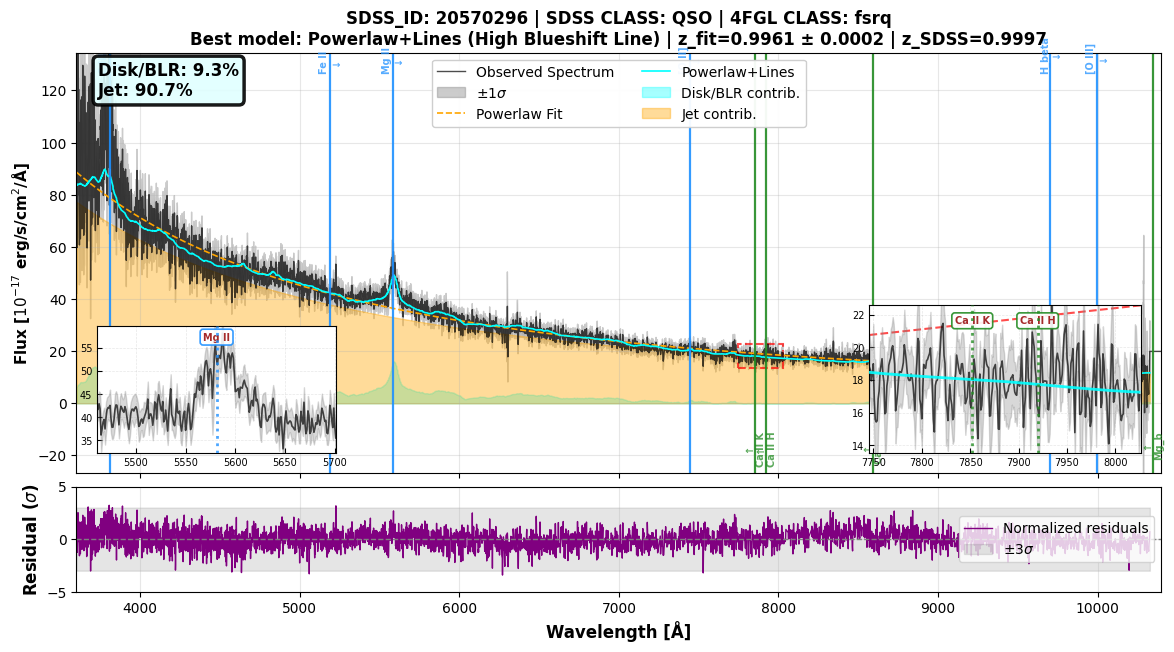


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [26]:
fig1, fig2 = plot_from_cache(results)

## 4. Customising the plot

Every aspect of the plot is controllable via keyword arguments.
Below are the most useful combinations.

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


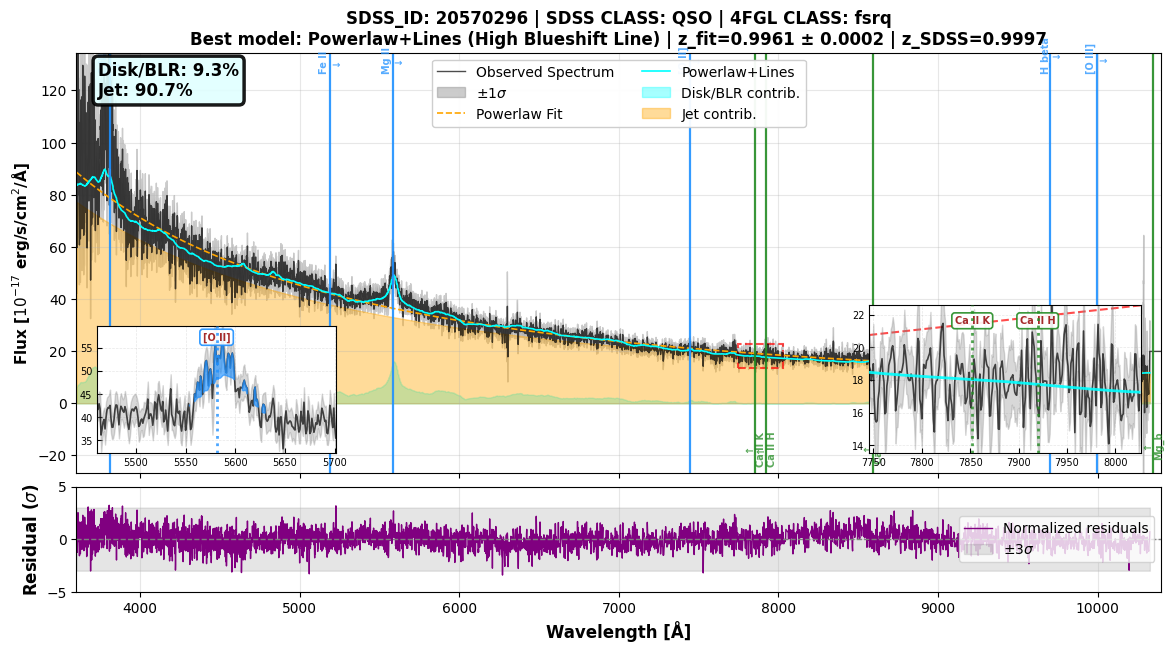


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [7]:
fig1, fig2 = plot_from_cache(results, show_fig1=False)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


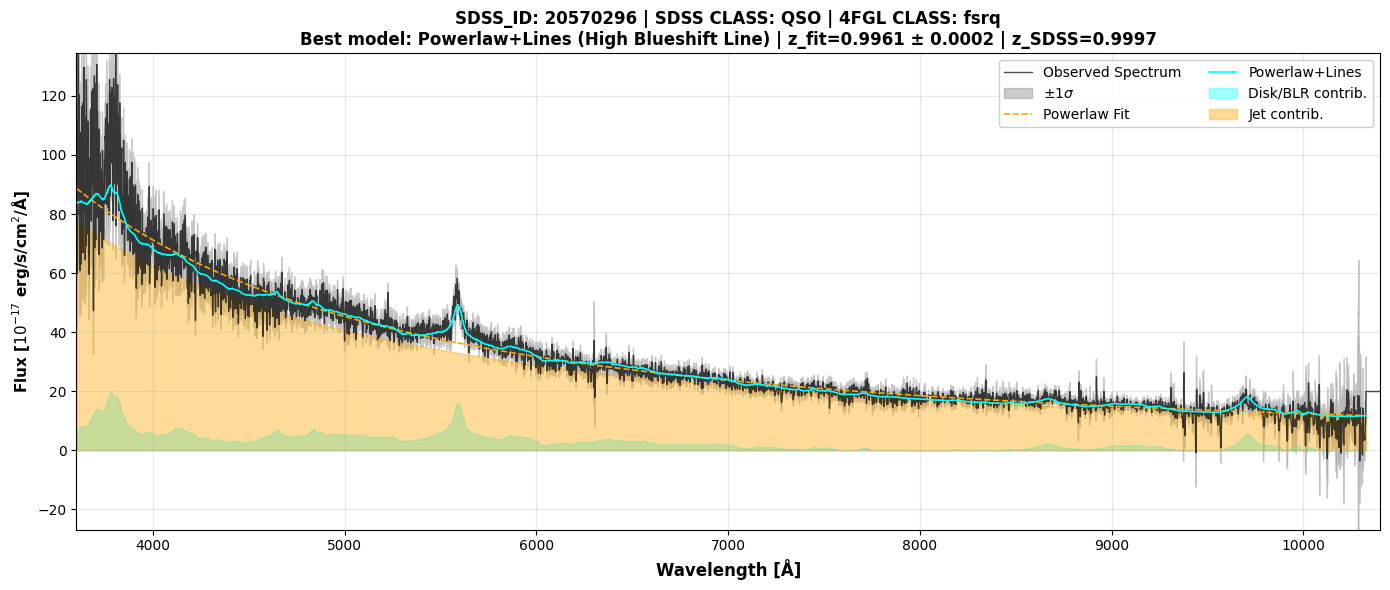


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [8]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1           = False,
    show_inset          = False,
    show_line_markers   = False,
    show_residuals      = False,
    show_fraction_label = False,
)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


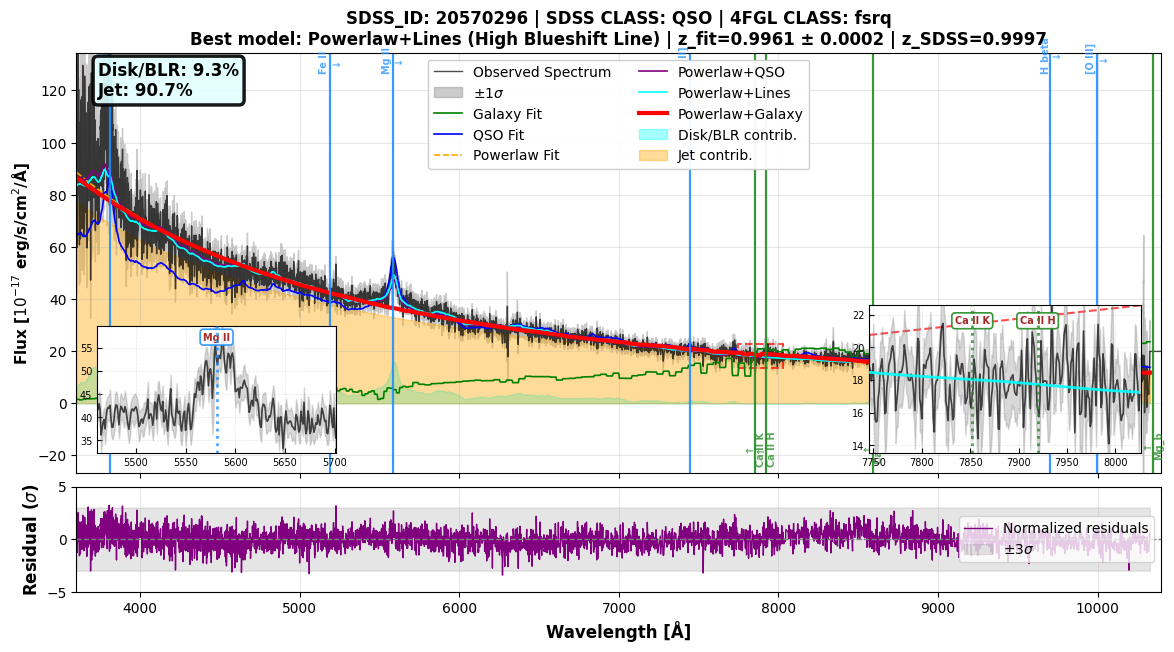


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [27]:
fig1, fig2 = plot_from_cache(results, show_fig1=False, models_to_show='all') 

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


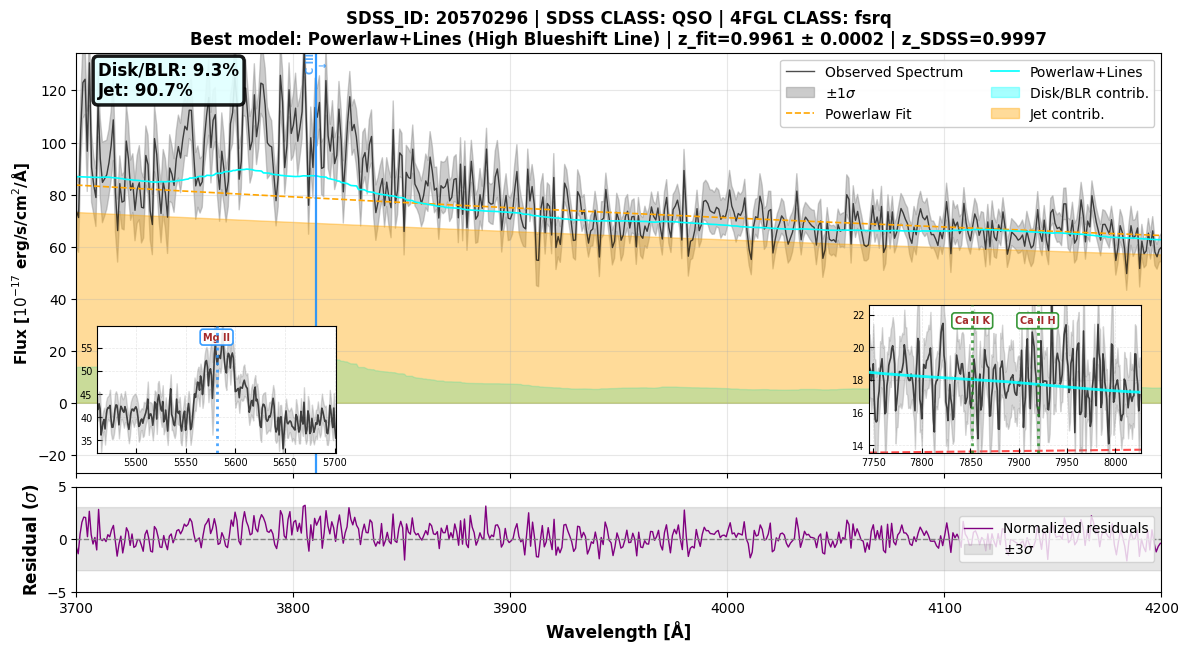


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [28]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1        = False,
    wavelength_range = (3700, 4200),
)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


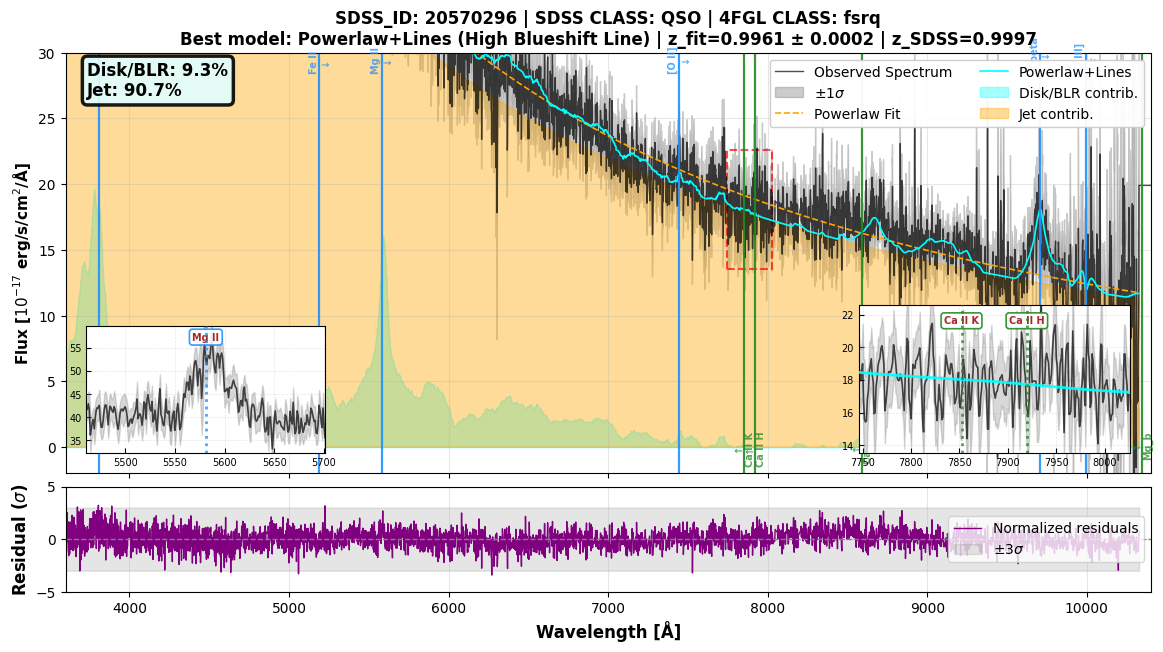


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [29]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1 = False,
    ylim      = (-2, 30),
)

  C III          : EW = -20.52 +/-  1.34 A, SNR = 15.3
  Mg II          : EW = -18.37 +/-  0.90 A, SNR = 20.5
  [O II]         : EW =  -2.40 +/-  0.64 A, SNR =  3.7
  H_beta         : EW = -25.53 +/-  2.20 A, SNR = 11.6
  [O III]        : EW =  -5.80 +/-  1.56 A, SNR =  3.7
  Ca II K        : EW =   2.94 +/-  0.84 A, SNR =  3.5
  Ca I G         : EW =   2.50 +/-  0.41 A, SNR =  6.0


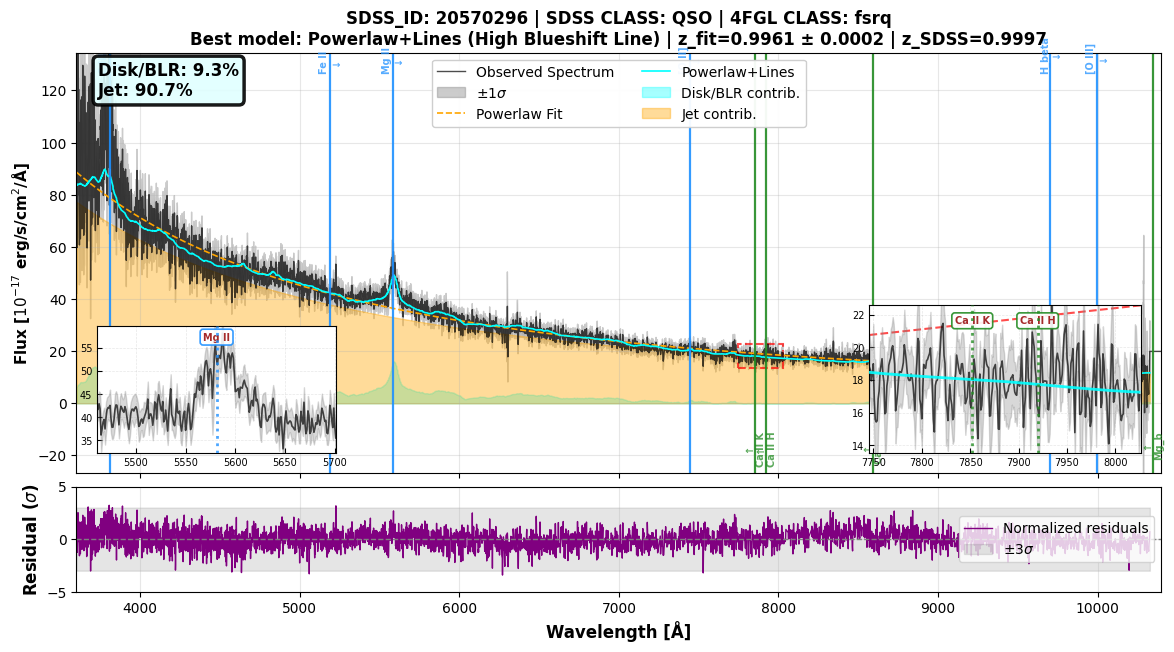

Saved: my_plots/20570296.pdf

SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [30]:
fig1, fig2 = plot_from_cache(
    results,
    show_fig1 = False,
    save_dir  = 'my_plots',
)

## 5. Equivalent width measurements

The pipeline measures equivalent widths for 16 emission and absorption
features using adaptive window selection. A line is detected if S/N ≥ 3.
Positive EW = absorption, negative EW = emission.

In [13]:
spec   = results['spectrum']
z_best = results['lmfit_results']['z_best']

results_ew = compute_EW_for_all_lines(
    spec['common_wave'],
    spec['flux_resamp'],
    spec['err_resamp'],
    spec['fit_mask'],
    z_best
)

print(f"Equivalent widths at z = {z_best:.4f}:")
print(f"\n{'Line':<15} {'Type':<12} {'EW (A)':>10} {'±err':>8} "
      f"{'S/N':>8} {'Detected':>10} {'Window':>8}")
print("─" * 75)
for name, obs, ew, ew_err, snr, detected, ltype, window in results_ew:
    if np.isfinite(ew):
        flag    = '✓' if detected else ''
        win_str = f'{window} A' if window is not None else ''
        print(f"{name:<15} {ltype:<12} {ew:>10.2f} {ew_err:>8.2f} "
              f"{snr:>8.1f} {flag:>10} {win_str:>8}")

Equivalent widths at z = 0.9961:

Line            Type             EW (A)     ±err      S/N   Detected   Window
───────────────────────────────────────────────────────────────────────────
C III           emission         -20.52     1.34     15.3          ✓     50 A
Fe II           emission           1.25     0.45      2.7                20 A
Mg II           emission         -18.37     0.90     20.5          ✓     50 A
[O II]          emission          -2.40     0.64      3.7          ✓     30 A
H_beta          emission         -25.53     2.20     11.6          ✓     80 A
[O III]         emission          -5.80     1.56      3.7          ✓     15 A
Ca II K         absorption         2.94     0.84      3.5          ✓     30 A
Ca II H         absorption        -2.45     0.87      2.8                30 A
Ca I G          absorption         2.50     0.41      6.0          ✓     15 A
Mg_b            absorption         3.32     2.08      1.6                30 A


## 6. Redshift posterior

The full p(z) posterior is stored for each source. Here we plot the global
posterior alongside the best-fit family contribution.

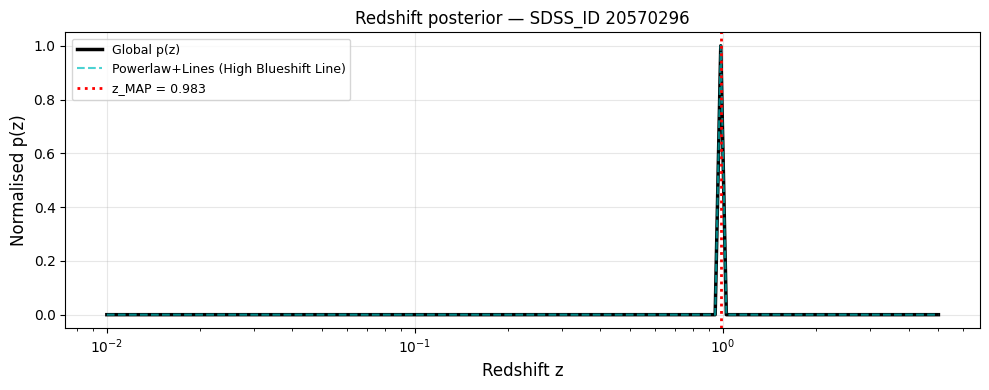


Top redshift solutions:
Rank          z  Rel. height   Note
────────────────────────────────────────
1        0.9829        1.000   primary


In [14]:
pz     = results['pz_results']
z_grid = results['chi2_grids']['z_grid']

# Map best label to family p(z)
family_pz_map = {
    'Powerlaw+Galaxy' : ('pz_galpl',  'r--'),
    'Powerlaw+QSO'    : ('pz_qsopl',  'm--'),
    'Powerlaw+Lines'  : ('pz_linepl', 'c--'),
    'Galaxy'          : ('pz_gal',    'g--'),
    'QSO'             : ('pz_qso',    'b--'),
    'Powerlaw'        : ('pz_pl',     'orange'),
}

best_label = results['lmfit_results']['best_label']
pz_key, style = next(
    ((v[0], v[1]) for k, v in family_pz_map.items()
     if best_label.startswith(k)),
    ('pz_gal', 'g--')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z_grid, normalize_shape(pz['p_total']), 'k-',  lw=2.5,
        label='Global p(z)')
ax.plot(z_grid, normalize_shape(pz[pz_key]),    style, lw=1.5, alpha=0.7,
        label=best_label)
ax.axvline(pz['z_map_total'], color='red', ls=':', lw=2,
           label=f"z_MAP = {pz['z_map_total']:.3f}")
ax.set_xscale('log')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Normalised p(z)', fontsize=12)
ax.set_title(f"Redshift posterior — SDSS_ID {meta['SDSS_ID']}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print top redshift solutions
peaks = get_redshift_peaks(pz['p_total'], z_grid)
print(f"\nTop redshift solutions:")
print(f"{'Rank':<6} {'z':>8} {'Rel. height':>12}   Note")
print("─" * 40)
for i, (z_peak, height) in enumerate(peaks[:3]):
    note = 'primary' if i == 0 else f'alternative {i}'
    print(f"{i+1:<6} {z_peak:>8.4f} {height:>12.3f}   {note}")

## 7. Access raw fit parameters

All best-fit parameters are stored in the cache for custom analysis.

In [15]:
lmfit = results['lmfit_results']

print("Best-fit parameters:")
print(f"\n{'Name':<15} {'Value':>12} {'Stderr':>12}")
print("─" * 42)
for name, param in lmfit['best_fit_params']['params'].items():
    val     = param['value']
    err     = param['stderr']
    err_str = f"{err:.4f}" if err is not None else 'N/A'
    print(f"{name:<15} {val:>12.4f} {err_str:>12}")

print(f"\nchi2:        {lmfit['best_fit_params']['chisqr']:.2f}")
print(f"redchi:      {lmfit['best_fit_params']['redchi']:.3f}")
print(f"AICc margin: {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:    {lmfit['pl_alpha']:.4f}")
print(f"PL delta:    {lmfit['pl_delta']:.4f}")

Best-fit parameters:

Name                   Value       Stderr
──────────────────────────────────────────
scale_line           83.5800       2.1015
A                    40.6766       0.1422
alpha                -1.2969       0.0318
delta                -1.2000       0.0793
lam0               5000.0000       0.0000
z                     0.9961       0.0002

chi2:        3312.51
redchi:      0.728
AICc margin: 49.0
PL alpha:    -1.2969
PL delta:    -1.2000


## 8. Loop over all sources in the cache

Extract key parameters from every cached source in bulk.

In [16]:
summary = []

for fname in sorted(cache.list_cached_objects()):
    parts   = fname.replace('.pkl.gz', '').split('_')
    sdss_id = parts[1]
    mjd     = int(parts[2]) if len(parts) > 2 else None

    try:
        res  = cache.load_object_results(sdss_id, mjd=mjd)
        lm   = res['lmfit_results']
        m    = res['metadata']
        c    = res['components']

        jet_frac = np.nan
        if lm['best_label'] == 'Powerlaw+Galaxy' and c['galpl_contrib']:
            jet_frac = c['galpl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+QSO') and c['qsopl_contrib']:
            jet_frac = c['qsopl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+Lines') and c['linepl_contrib']:
            jet_frac = c['linepl_contrib']['frac_pl']

        summary.append({
            'SDSS_ID'    : sdss_id,
            'MJD'        : mjd,
            'best_label' : lm['best_label'],
            'z_best'     : lm['z_best'],
            'z_sdss'     : m['z_sdss'],
            'fermi_class': m['fermi_class'],
            'jet_frac'   : jet_frac,
            'pl_alpha'   : lm['pl_alpha'],
            'aicc_margin': lm['aicc_margin'],
            'sn'         : m['sn_median'],
        })
    except Exception as e:
        print(f"  Skipped {fname}: {e}")

print(f"\nLoaded {len(summary)} sources successfully")
print(f"\n{'SDSS_ID':<15} {'Best model':<20} {'z_fit':>8} "
      f"{'Jet frac':>10} {'S/N':>6}")
print("─" * 65)
for s in summary:
    jf = f"{s['jet_frac']*100:.1f}%" if np.isfinite(s['jet_frac']) else 'N/A'
    print(f"{s['SDSS_ID']:<15} {s['best_label']:<20} "
          f"{s['z_best']:>8.4f} {jf:>10} {s['sn']:>6.1f}")

Found 3 cached objects in /Users/s2822744/Desktop/test_cache/
Loaded: obj_13362106_59199.pkl.gz
Loaded: obj_15606475_60162.pkl.gz
Loaded: obj_20570296_60027.pkl.gz

Loaded 3 sources successfully

SDSS_ID         Best model              z_fit   Jet frac    S/N
─────────────────────────────────────────────────────────────────
13362106        Powerlaw+Galaxy        0.6739      29.5%    2.3
15606475        Galaxy                 0.3927        N/A    1.7
20570296        Powerlaw+Lines (High Blueshift Line)   0.9961      90.7%   10.5


## 9. Multi-object comparison plot

Compare multiple sources side by side in a single figure.
Load the VAC table from the SDSS SAS to select sources of interest.

In [17]:
from astropy.table import Table
from astropy.io import fits

# Load VAC table — download from SDSS SAS (link in README)
# vac = Table(fits.open('fermi_blazar_vac_dr20.fits')[1].data)

# For this demo we use all three sources from the test cache
object_list = [
    {'SDSS_ID': 13362106, 'MJD': 59199},
    {'SDSS_ID': 15606475, 'MJD': 60162},
    {'SDSS_ID': 20570296, 'MJD': 60027},
]

# Note: plot_multi_object_comparison_single requires the full VAC table
# to look up source metadata. Uncomment the vac line above first.
# fig = plot_multi_object_comparison_single(
#     object_list = object_list,
#     cache       = cache,
#     final_bl    = vac,
#     n_cols      = 2,
#     save_dir    = 'my_plots'
# )

## 10. Classification summary

`classification_summary` prints a one-line human-readable description
of the source — its blazar class, jet fraction, and key detected lines.
Useful for quickly understanding a source without looking at the plots.

In [ ]:
# One-line classification summary
summary = classification_summary(results)

## 11. Equivalent width summary plot

`plot_ew_summary` produces a bar chart of all detected spectral lines.
Blue bars are emission lines, green bars are absorption lines.
The red dashed line marks the |EW| = 5 Å BL Lac/FSRQ boundary.
S/N values are labelled on each bar.

In [ ]:
fig = plot_ew_summary(results, min_snr=3.0)

## 12. Epoch comparison

`compare_epochs` overlays spectra from multiple observations of the same
source, coloured from dark (earliest) to bright (latest MJD).
The lower panel shows the flux ratio of each epoch relative to the first,
making spectral variability immediately visible.

This is particularly useful for identifying **changing-look blazar candidates**
— sources that transition between BL Lac and FSRQ behaviour over time.

Here we demonstrate with the three sources in the test cache as separate
entries, but in the full sample you would pass multiple MJDs for the
**same** SDSS_ID to compare epochs of a single source.

In [ ]:
# Example: compare two epochs of source 20570296
# (In the full cache, sources with multiple observations will have
#  multiple MJD values available — use cache.list_cached_objects()
#  to find them)

# For demonstration with the test cache, we compare the single available
# epoch against itself to show the function structure:
fig = compare_epochs(
    sdss_id         = '20570296',
    mjd_list        = [60027],          # add more MJDs here for real comparison
    cache           = cache,
    wavelength_range= (3600, 10400),
    show_model      = True,
    save_dir        = None
)

## 13. Population plot

`plot_population` takes a list of cached results and produces a
scatter plot of any two parameters alongside their distributions.

Available parameters: `'z_best'`, `'jet_frac'`, `'pl_alpha'`,
`'pl_delta'`, `'aicc_margin'`, `'sn'`

Colour by: `'best_label'` (model family) or `'fermi_class'`

This is most informative with the full 707-source cache.
Here we demonstrate with the 3 test sources.

In [ ]:
# First load all sources from the test cache into a list
results_list = []
for fname in sorted(cache.list_cached_objects()):
    parts   = fname.replace('.pkl.gz', '').split('_')
    sdss_id = parts[1]
    mjd     = int(parts[2]) if len(parts) > 2 else None
    try:
        results_list.append(cache.load_object_results(sdss_id, mjd=mjd))
    except Exception as e:
        print(f'  Skipped {fname}: {e}')

print(f'Loaded {len(results_list)} sources for population plot')

In [ ]:
# Jet fraction vs redshift, coloured by model family
fig = plot_population(
    results_list,
    x_param  = 'z_best',
    y_param  = 'jet_frac',
    color_by = 'best_label'
)

In [ ]:
# PL alpha vs jet fraction, coloured by Fermi class
fig = plot_population(
    results_list,
    x_param  = 'pl_alpha',
    y_param  = 'jet_frac',
    color_by = 'fermi_class'
)